# Notebook 02b: Appendix Diagnostics and Extension Scaffold

This notebook is not mainline. It only keeps diagnostics that support Notebook 02 or scaffold a named future extension.

Removed from this notebook: Phillips/output-gap forecast block and active IV diagnostics. Those introduce separate estimands and do not support the main short-run TWFE story.


## Guardrails

- Driscoll-Kraay rows are inference sensitivity for the same TWFE coefficient.
- Distributed-lag estimates are reduced-form associations, not causal impulse responses.
- Any IV, inflation-targeting, or Phillips-curve work belongs in a separate explicitly exploratory notebook.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
FIG_DIR = ROOT / "04_current_results/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing required file: {PANEL_PATH}")

ROOT


PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

### Load panel and helpers


In [2]:
panel = (
    pd.read_csv(PANEL_PATH)
    .rename(columns={"Country Name": "country"})
    .sort_values(["country", "year"])
    .copy()
)


def fit_inflation_twfe(df, cov_type="clustered", **fit_kwargs):
    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    fit_df = df.dropna(subset=["inflation", "m2_growth"]).set_index(["country", "year"]).sort_index()
    formula = "inflation ~ 1 + m2_growth + EntityEffects + TimeEffects"
    return PanelOLS.from_formula(formula, data=fit_df).fit(cov_type=cov_type, **fit_kwargs)


def coef_row(label, sample, res, cov="clustered_by_country"):
    return {
        "label": label,
        "sample": sample,
        "covariance": cov,
        "coef_m2_growth": float(res.params["m2_growth"]),
        "se": float(res.std_errors["m2_growth"]),
        "t_stat": float(res.tstats["m2_growth"]),
        "p_value": float(res.pvalues["m2_growth"]),
        "within_r2": float(res.rsquared_within),
        "nobs": int(res.nobs),
    }

clean_panel = panel[panel["sample_low_inflation"] == 1].copy()


### Inference sensitivity: Driscoll-Kraay

Same TWFE coefficient as Notebook 02, different covariance estimator. This is an appendix diagnostic, not a new result.


In [3]:
dk_rows = [
    coef_row(
        "driscoll_kraay_bw4",
        "full",
        fit_inflation_twfe(panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
    coef_row(
        "driscoll_kraay_bw4",
        "clean_low_inflation",
        fit_inflation_twfe(clean_panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
]
dk_table = pd.DataFrame(dk_rows)
display(dk_table[["sample", "coef_m2_growth", "se", "t_stat", "p_value", "nobs"]])


,sample,coef_m2_growth,se,t_stat,p_value,nobs
0,full,0.664851,0.225793,2.944519,0.003251,4750
1,clean_low_inflation,0.040292,0.027670,1.456181,0.145433,3639


### Distributed-lag scaffold: cumulative association

This block estimates contemporaneous and lagged associations of M2 growth with inflation using entity and year fixed effects.

It is not a causal IRF. Its only purpose is to scaffold a possible cumulative distributed-lag extension.


In [4]:
lag = panel[panel["sample_main"] == 1].copy().sort_values(["country", "year"])
lag["m2_l1"] = lag.groupby("country")["m2_growth"].shift(1)
lag["m2_l2"] = lag.groupby("country")["m2_growth"].shift(2)
lag = lag.dropna(subset=["m2_growth", "m2_l1", "m2_l2", "inflation"])
lag_panel = lag.set_index(["country", "year"])

lag_res = PanelOLS.from_formula(
    "inflation ~ m2_growth + m2_l1 + m2_l2 + EntityEffects + TimeEffects",
    data=lag_panel,
    drop_absorbed=True,
).fit(cov_type="clustered", cluster_entity=True)

terms = ["m2_growth", "m2_l1", "m2_l2"]
term_table = pd.DataFrame({
    "term": terms,
    "coef": [float(lag_res.params[t]) for t in terms],
    "se": [float(lag_res.std_errors[t]) for t in terms],
    "p_value": [float(lag_res.pvalues[t]) for t in terms],
})

cov = lag_res.cov.loc[terms, terms].to_numpy()
beta = lag_res.params.loc[terms].to_numpy()
weights = {
    "h0": np.array([1.0, 0.0, 0.0]),
    "h0_plus_h1": np.array([1.0, 1.0, 0.0]),
    "h0_plus_h1_plus_h2": np.array([1.0, 1.0, 1.0]),
}

cum_rows = []
for label, w in weights.items():
    est = float(w @ beta)
    se = float(np.sqrt(w @ cov @ w))
    cum_rows.append({
        "cumulative_horizon": label,
        "estimate": est,
        "se": se,
        "ci_low_95": est - 1.96 * se,
        "ci_high_95": est + 1.96 * se,
    })

cum_table = pd.DataFrame(cum_rows)
display(term_table)
display(cum_table)


,term,coef,se,p_value
0,m2_growth,0.337684,0.117845,4.184298e-03
1,m2_l1,0.256495,0.048216,1.093065e-07
2,m2_l2,0.131816,0.035490,2.064634e-04


,cumulative_horizon,estimate,se,ci_low_95,ci_high_95
0,h0,0.337684,0.117845,0.106707,0.568661
1,h0_plus_h1,0.594179,0.163560,0.273600,0.914757
2,h0_plus_h1_plus_h2,0.725994,0.170755,0.391314,1.060674


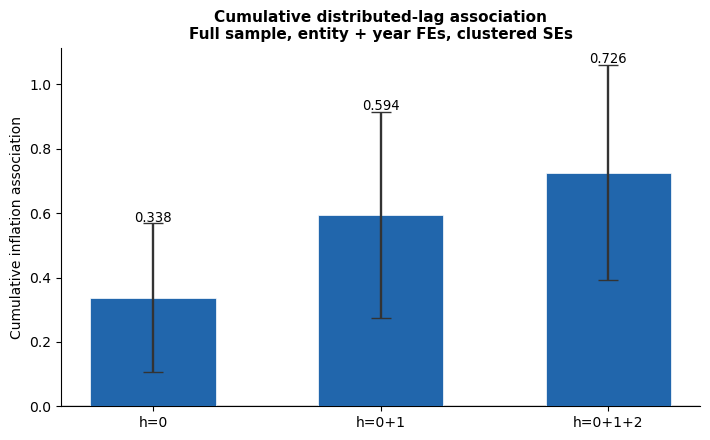

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
x = np.arange(len(cum_table))
labels = ["h=0", "h=0+1", "h=0+1+2"]

ax.bar(x, cum_table["estimate"], color="#2166ac", width=0.55, edgecolor="white", lw=0.5, zorder=3)
ax.errorbar(
    x,
    cum_table["estimate"],
    yerr=1.96 * cum_table["se"],
    fmt="none",
    color="#333333",
    capsize=7,
    lw=1.7,
    zorder=4,
)
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Cumulative inflation association")
ax.set_title(
    "Cumulative distributed-lag association\nFull sample, entity + year FEs, clustered SEs",
    fontsize=11,
    fontweight="bold",
)
for i, row in cum_table.iterrows():
    ax.text(i, row["estimate"] + 1.96 * row["se"] + 0.005, f"{row['estimate']:.3f}", ha="center", fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIG_DIR / "distributed_lag_cumulative_association.png", dpi=150, bbox_inches="tight")
plt.show()


### Appendix read


In [6]:
print("Appendix read:")
print("1. Driscoll-Kraay rows are inference sensitivity for the same TWFE association in Notebook 02.")
print("2. Distributed-lag estimates are reduced-form cumulative associations, not causal impulse responses.")
print("3. Phillips/output-gap and IV diagnostics were removed from this notebook to keep the estimand clean.")


Appendix read:
1. Driscoll-Kraay rows are inference sensitivity for the same TWFE association in Notebook 02.
2. Distributed-lag estimates are reduced-form cumulative associations, not causal impulse responses.
3. Phillips/output-gap and IV diagnostics were removed from this notebook to keep the estimand clean.
